# CSCE 580 – Quiz 1
## Q2: Programming activity – Resume analysis

**Instructions (from the quiz):**
- Task 1: Analyze *your* resume text: top 20 words, then remove stopwords and plot again; discuss findings.
- Task 2: Analyze *all resumes in the class folder*: top 20 words, then remove stopwords and plot again; discuss.
- Task 3: Compare your specific words to the class and note which are unique.

> Fill in the `my_resume_path` and `class_folder_path` below, then run all cells.


In [1]:
# Path setup — EDIT THESE to use the repo structure
# Run this notebook from Quiz1/code/. It will write outputs to ../data and ../figures
my_resume_path = '../pedroresume.txt'                    # e.g., a plain-text export of your resume
class_folder_path = '../StudentResumes'                  # folder with all resumes (pdf/docx/txt)
fig_dir = '../figures'                                   # where to save PNGs
data_dir = '../data'                                     # where to save CSVs


In [2]:
import os, re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Utilities for reading resumes
import pdfplumber
from docx import Document

Path(fig_dir).mkdir(parents=True, exist_ok=True)
Path(data_dir).mkdir(parents=True, exist_ok=True)

def read_pdf(path):
    text_parts = []
    with pdfplumber.open(str(path)) as pdf:
        for page in pdf.pages:
            text_parts.append(page.extract_text() or "")
    return "\n".join(text_parts)

def read_docx(path):
    doc = Document(str(path))
    return "\n".join(p.text for p in doc.paragraphs)

def read_any(path: Path) -> str:
    ext = path.suffix.lower()
    try:
        if ext == '.pdf':
            return read_pdf(path)
        elif ext == '.docx':
            return read_docx(path)
        elif ext == '.txt':
            return path.read_text(encoding='utf-8', errors='ignore')
        else:
            # fallback best-effort
            return path.read_text(encoding='utf-8', errors='ignore')
    except Exception:
        return ''


### Stopword list
We embed the common 127 English stopwords often used for resume/text preprocessing.

In [3]:
try:
    from nltk.corpus import stopwords
    STOPWORDS = set(w.lower() for w in stopwords.words("english"))
except Exception:
    # fallback to your local file if NLTK data isn't available
    STOPWORDS = load_stopwords_auto("/NLTK")



### Tokenization helpers

In [4]:
WORD_RE = re.compile(r"[A-Za-z][A-Za-z+'-]*")

def tokenize(text: str):
    text = text.lower()
    return WORD_RE.findall(text)

from collections import Counter

def top_n_words(words, n=20):
    c = Counter(words)
    return pd.DataFrame(c.most_common(n), columns=['word','count'])


## Task 1 – Your resume

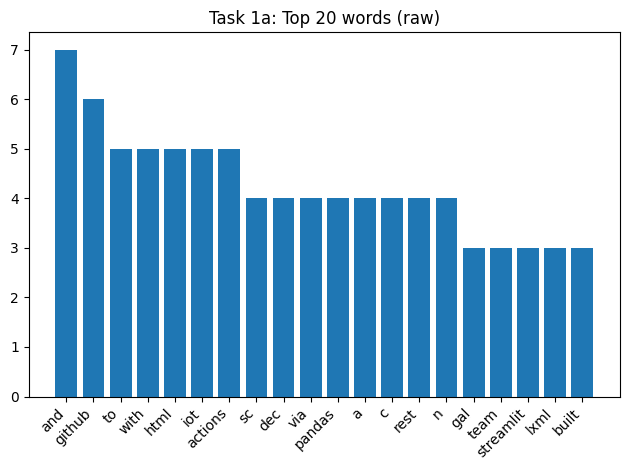

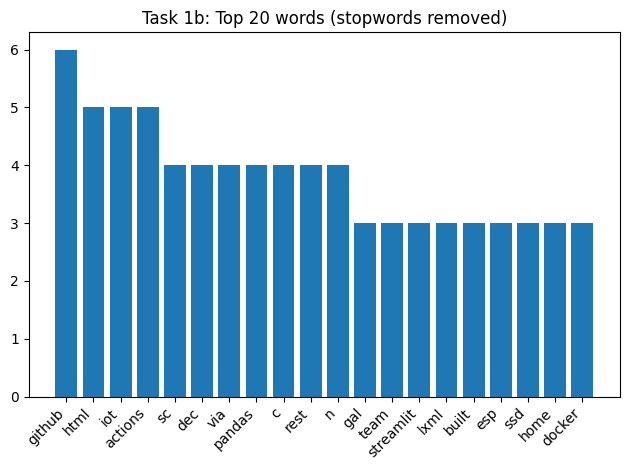

In [5]:
# 1) Load
my_text = read_any(Path(my_resume_path))
assert my_text.strip(), 'Could not read your resume text. Check `my_resume_path`.'

# 2) Tokenize
my_words = tokenize(my_text)

# 3) Plot top-20 raw words
my_top20 = top_n_words(my_words, 20)
my_top20.to_csv(f"{data_dir}/my_top20_raw.csv", index=False)

plt.figure()
plt.bar(my_top20['word'], my_top20['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Task 1a: Top 20 words (raw)')
plt.tight_layout()
plt.savefig(f"{fig_dir}/task1a_my_top20_raw.png", dpi=150)
plt.show()

# 4) Remove stopwords
my_specific = [w for w in my_words if w not in STOPWORDS]
my_top20_specific = top_n_words(my_specific, 20)
my_top20_specific.to_csv(f"{data_dir}/my_top20_specific.csv", index=False)

plt.figure()
plt.bar(my_top20_specific['word'], my_top20_specific['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Task 1b: Top 20 words (stopwords removed)')
plt.tight_layout()
plt.savefig(f"{fig_dir}/task1b_my_top20_specific.png", dpi=150)
plt.show()


> **Task 1c – Short analysis (fill-in):**
- Which words emerged after removing stopwords?
- Did removing stopwords better reflect your skills or experience?

*(Write your notes here in the notebook or in your Responses doc.)*

## Task 2 – Class folder of resumes

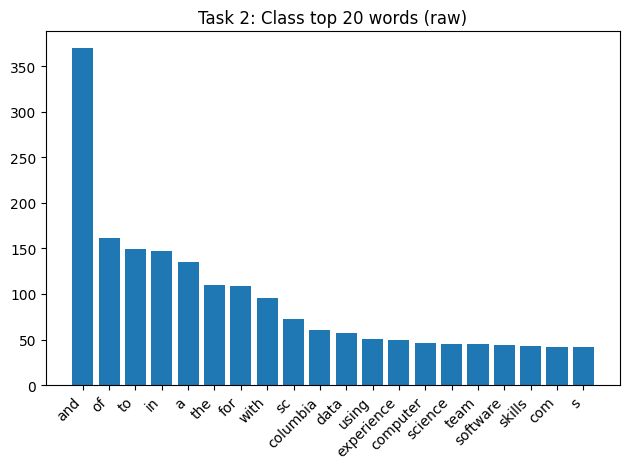

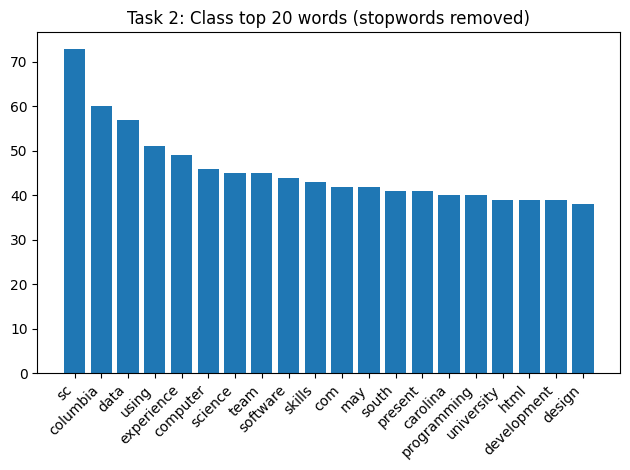

In [6]:
# 1) Load all resumes
all_rows = []
for p in Path(class_folder_path).rglob('*'):
    if not p.is_file():
        continue
    if p.suffix.lower() in {'.pdf','.docx','.txt'}:
        txt = read_any(p) or ''
        if txt.strip():
            all_rows.append({'filename': str(p), 'text': txt})

assert all_rows, 'No readable resumes found. Check `class_folder_path`.'
class_df = pd.DataFrame(all_rows)
class_df.to_csv(f"{data_dir}/class_texts.csv", index=False)

# 2) Tokenize whole-corpus words
all_words = []
for t in class_df['text']:
    all_words.extend(tokenize(t))

# 3) Top-20 (raw)
class_top20 = top_n_words(all_words, 20)
class_top20.to_csv(f"{data_dir}/class_top20_raw.csv", index=False)

plt.figure()
plt.bar(class_top20['word'], class_top20['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Task 2: Class top 20 words (raw)')
plt.tight_layout()
plt.savefig(f"{fig_dir}/task2_class_top20_raw.png", dpi=150)
plt.show()

# 4) Remove stopwords
class_specific = [w for w in all_words if w not in STOPWORDS]
class_top20_specific = top_n_words(class_specific, 20)
class_top20_specific.to_csv(f"{data_dir}/class_top20_specific.csv", index=False)

plt.figure()
plt.bar(class_top20_specific['word'], class_top20_specific['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Task 2: Class top 20 words (stopwords removed)')
plt.tight_layout()
plt.savefig(f"{fig_dir}/task2_class_top20_specific.png", dpi=150)
plt.show()


> **Task 2 – Short analysis (fill-in):**
- Which domain words emerge for the class?
- Did removing stopwords reveal more about the class’s skill mix?

## Task 3 – What is unique to you?

In [7]:
my_set = set(my_specific)
class_set = set(class_specific)
unique_to_me = sorted(my_set - class_set)

pd.Series(unique_to_me, name='unique_words').to_csv(f"{data_dir}/task3_unique_words.csv", index=False)
print(f"Unique words to me (count={len(unique_to_me)}):\n", unique_to_me[:50])


Unique words to me (count=0):
 []


---
### (Optional) Use your existing NLP pipeline
You can also drop your `resume_keywords.csv` and run your `keywords.py` / `extract_attention.py`
workflow to generate richer reports alongside this notebook.